# Improved DDPG for MountainCarContinuous-v0

This notebook is the **improved companion** to the source-matched MountainCarContinuous DDPG notebook.

The source-matched reproduction was valuable because it showed a real failure mode:

$$
\boxed{
\text{the actor learned almost zero action instead of learning to reach the goal}
}
$$

That behavior is understandable from the native MountainCarContinuous reward. Before the goal is discovered, the agent mainly sees the action penalty:

$$
R_t=-0.1a_t^2.
$$

Therefore a policy that produces:

$$
a_t\approx0
$$

can receive a reward near zero without solving the task.

This notebook keeps the same DDPG idea and closely related actor/critic architecture, but makes several explicit improvements so that the agent receives a more useful learning signal while still being evaluated using the **original Gymnasium reward**.

## 1. What is changed?

The improved implementation makes the following changes.

| Component | Source-matched version | Improved version |
|---|---|---|
| Target-network initialization | Independent cloned weights | Copy online weights initially |
| Terminal target | Always bootstraps | Mask bootstrap on true termination |
| Replay action | Pre-clipped action | Actual action executed by environment |
| Exploration | Fixed source behavior | OU noise with decaying scale |
| Replay warm-up | Starts as soon as batch is available | Dedicated warm-up period |
| Learning reward | Native reward only | Native reward + potential-based shaping |
| Evaluation reward | Native reward | Native reward |
| Success metric | Goal position | Goal position |
| Critic stabilization | MSE only | MSE + gradient clipping |

The purpose is not to rewrite the original experiment silently.

The original notebook remains the **source reproduction**.

This notebook is the **improved learning experiment**.

## 2. MountainCarContinuous state

The state is:

$$
\boxed{
S_t=
[x_t,\dot{x}_t]
}
$$

where:

- $x_t$ = position,
- $\dot{x}_t$ = velocity.

The observation limits are approximately:

$$
x_t\in[-1.2,0.6]
$$

and:

$$
\dot{x}_t\in[-0.07,0.07].
$$

## 3. Continuous action

The actor produces one continuous action:

$$
\boxed{
A_t=\mu(S_t;\theta^\mu)
}
$$

with:

$$
\boxed{
-1\leq A_t\leq1.
}
$$

Negative force pushes left.

Positive force pushes right.

The car normally needs to first move away from the goal, build momentum, and then accelerate toward the right hill.

## 4. Native environment reward

The environment's original reward is still the primary performance measure.

Before reaching the goal, the reward contains an action penalty:

$$
\boxed{
R_t^{native}=-0.1A_t^2.
}
$$

Reaching the goal provides the large positive goal reward.

This creates a difficult exploration problem.

If the goal is never discovered, the actor can improve its immediate reward simply by reducing action magnitude:

$$
|A_t|\rightarrow0.
$$

That was the failure mode observed in the source-matched notebook.

## 5. Why the source-matched agent can collapse to zero action

Suppose the car never reaches the goal.

Compare two actions.

### Large action

If:

$$
A_t=1,
$$

then:

$$
R_t=-0.1(1)^2=-0.1.
$$

### Near-zero action

If:

$$
A_t=0.05,
$$

then:

$$
R_t=-0.1(0.05)^2=-0.00025.
$$

Before the goal bonus is discovered:

$$
-0.00025>-0.1.
$$

So the critic may teach the actor that weak action is better.

The result can be:

$$
\boxed{
\mu(S_t)\approx0
}
$$

even though the car never climbs the mountain.

## 6. Improvement 1: initialize target networks correctly

Standard DDPG begins with target-network weights equal to the online-network weights:

$$
\boxed{
\theta^{\mu'}
\leftarrow
\theta^\mu
}
$$

and:

$$
\boxed{
\theta^{Q'}
\leftarrow
\theta^Q.
}
$$

This gives the target networks the same initial function as the online networks.

The source implementation created cloned architectures but did not explicitly copy the online weights.

The improved notebook copies them immediately.

## 7. Improvement 2: terminal masking

The improved critic target is:

$$
\boxed{
Y_t
=
R_t^{learn}
+
\gamma(1-d_t)
Q'
\left(
S_{t+1},
\mu'(S_{t+1})
\right)
}
$$

where:

$$
d_t=1
$$

only for a **true environment termination**.

A Gymnasium time-limit truncation is not treated as physical termination for the bootstrap target.

This follows the distinction between:

```text
terminated
```

and:

```text
truncated
```

in the modern Gymnasium API.

## 8. Improvement 3: store the action actually executed

The source-matched implementation could produce an exploratory action outside:

$$
[-1,1].
$$

The wrapper clipped that action before environment execution, but replay could contain the unclipped value.

For example:

$$
A_t^{raw}=1.4
$$

while the environment actually received:

$$
A_t^{env}=1.0.
$$

The improved notebook stores:

$$
\boxed{
A_t^{replay}=A_t^{env}.
}
$$

Therefore the critic learns from the same action that generated the observed transition and reward.

## 9. Improvement 4: decaying OU exploration

The actor action during training is:

$$
A_t^{raw}
=
\mu(S_t)
+
\beta_e X_t
$$

where:

- $X_t$ = Ornstein-Uhlenbeck process,
- $\beta_e$ = exploration scale at episode $e$.

The executed action is:

$$
\boxed{
A_t
=
\operatorname{clip}
\left(
A_t^{raw},
-1,
1
\right).
}
$$

The noise scale decays gradually:

$$
\boxed{
\beta_e
=
\max
\left(
\beta_{min},
\beta_0\lambda^e
\right).
}
$$

This gives strong exploration early and a more deterministic actor later.

## 10. Improvement 5: replay warm-up

Before updating the networks, the replay memory is allowed to collect a diverse set of transitions.

For the first:

$$
\boxed{
N_{warmup}
}
$$

steps, actions are generated primarily for exploration.

Only after the warm-up does gradient-based DDPG training begin.

This prevents the actor and critic from immediately overfitting to a very small set of early experiences.

## 11. Improvement 6: potential-based reward shaping

The environment's original reward is still stored for reporting.

A separate reward is used for learning:

$$
\boxed{
R_t^{learn}
=
R_t^{native}
+
F(S_t,S_{t+1}).
}
$$

The shaping term has the potential-based form:

$$
\boxed{
F(S_t,S_{t+1})
=
\lambda_\Phi
\left[
\gamma\Phi(S_{t+1})
-
\Phi(S_t)
\right].
}
$$

Potential-based shaping is useful because it provides intermediate information without simply replacing the original objective.

## 12. Potential function

MountainCar needs two things:

1. movement,
2. elevation.

The potential function therefore combines a normalized hill-height proxy with normalized speed:

$$
\boxed{
\Phi(s)
=
h(x)
+
c_v
\frac{|v|}{v_{max}}.
}
$$

The height proxy is:

$$
\boxed{
h(x)
=
0.45\sin(3x)+0.55.
}
$$

The velocity term rewards gaining momentum in **either direction**:

$$
|v|.
$$

This is important because the optimal behavior normally involves moving left before moving right.

## 13. Native reward and learning reward stay separate

The training loop records both:

$$
R_t^{native}
$$

and:

$$
R_t^{learn}.
$$

The learning reward is used only inside the critic update.

All meaningful task-performance plots use:

- native episode reward,
- maximum position,
- goal-reaching rate,
- deterministic evaluation reward.

Therefore the notebook cannot claim success merely because the shaping reward becomes large.

The car must actually move toward and reach the goal.

## 14. Actor and critic

The improved notebook keeps the same basic source architecture.

### Actor

$$
\boxed{
2\rightarrow64\rightarrow64\rightarrow1
}
$$

with:

$$
\tanh
$$

at the output.

### Critic

State branch:

$$
2\rightarrow32
$$

Action branch:

$$
1\rightarrow32
$$

Concatenate:

$$
64\rightarrow1.
$$

The purpose is to improve the training procedure rather than replace the model with a much larger network.

## 15. DDPG critic update

For a sampled mini-batch:

$$
\left(
S_i,A_i,R_i,S_i',d_i
\right),
$$

the target actor calculates:

$$
A_i'
=
\mu'(S_i').
$$

The target critic calculates:

$$
Q_i'
=
Q'(S_i',A_i').
$$

The target is:

$$
\boxed{
Y_i
=
R_i^{learn}
+
\gamma(1-d_i)Q_i'.
}
$$

The critic minimizes:

$$
\boxed{
L_Q
=
\frac1N
\sum_i
\left[
Y_i-Q(S_i,A_i)
\right]^2.
}
$$

## 16. DDPG actor update

The actor attempts to maximize the critic's value estimate.

The implemented loss is:

$$
\boxed{
L_\mu
=
-\frac1N
\sum_i
Q(S_i,\mu(S_i)).
}
$$

Gradient descent on this loss is equivalent to moving the actor toward actions the critic estimates as more valuable.

## 17. Soft target update

After a gradient update:

$$
\boxed{
\theta'
\leftarrow
\tau\theta
+
(1-\tau)\theta'.
}
$$

The notebook uses:

$$
\boxed{
\tau=0.001.
}
$$

## 18. Colab setup

In [31]:
%pip -q install "gymnasium[classic-control]" imageio imageio-ffmpeg

In [32]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import gymnasium as gym
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import RandomUniform
from IPython.display import display, Video
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
print("TensorFlow:", tf.__version__)
print("Gymnasium:", gym.__version__)

TensorFlow: 2.21.0
Gymnasium: 1.3.0


## 19. Inspect MountainCarContinuous-v0

In [33]:
inspect_env = gym.make("MountainCarContinuous-v0")
state, info = inspect_env.reset(seed=SEED)
print("Initial state:", state)
print("Observation space:", inspect_env.observation_space)
print("Action space:", inspect_env.action_space)
print("Goal position:", inspect_env.unwrapped.goal_position)
inspect_env.close()

Initial state: [-0.4452  0.    ]
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Box(-1.0, 1.0, (1,), float32)
Goal position: 0.45


## 20. Improved training configuration

In [34]:
QUICK_RUN = False
NUM_EPISODES = 50 if QUICK_RUN else 500
GAMMA = 0.99
TAU = 0.001
BATCH_SIZE = 64
REPLAY_CAPACITY = 100000
WARMUP_STEPS = 2000
LEARN_EVERY = 1
UPDATES_PER_STEP = 1
ACTOR_LEARNING_RATE = 0.0005
CRITIC_LEARNING_RATE = 0.001
INITIAL_NOISE_SCALE = 1.0
MIN_NOISE_SCALE = 0.10
NOISE_DECAY = 0.995
OU_THETA = 0.15
OU_SIGMA = 0.30
OU_DT = 1.0
SHAPING_SCALE = 10.0
VELOCITY_POTENTIAL_WEIGHT = 0.50
EVAL_EVERY = 10
SAVE_EVERY = 50
AGENT_PATH = "mountain_car_continuous_improved"
print("Episodes:", NUM_EPISODES)
print("Warm-up steps:", WARMUP_STEPS)
print("Shaping scale:", SHAPING_SCALE)

Episodes: 500
Warm-up steps: 2000
Shaping scale: 10.0


## 21. Actor network

In [35]:
def build_actor():
    state_input = Input(shape=(2,))
    x = Dense(64, activation="relu")(state_input)
    x = Dense(64, activation="relu")(x)
    output = Dense(1, activation="tanh", kernel_initializer=RandomUniform(minval=-0.003, maxval=0.003))(x)
    actor = Model(inputs=state_input, outputs=output)
    actor.optimizer = Adam(learning_rate=ACTOR_LEARNING_RATE)
    return actor

actor_demo = build_actor()
actor_demo.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

## 22. Critic network

In [36]:
def build_critic():
    state_input = Input(shape=(2,))
    action_input = Input(shape=(1,))
    state_features = Dense(32, activation="relu")(state_input)
    action_features = Dense(32, activation="relu")(action_input)
    x = Concatenate()([state_features, action_features])
    x = Dense(64, activation="relu")(x)
    output = Dense(1, activation="linear", kernel_initializer=RandomUniform(minval=-0.003, maxval=0.003))(x)
    critic = Model(inputs=[state_input, action_input], outputs=output)
    critic.optimizer = Adam(learning_rate=CRITIC_LEARNING_RATE)
    return critic

critic_demo = build_critic()
critic_demo.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 32)        │         96 │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 32)        │         64 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 64)        │          0 │ dense_24[0][0],   │
│ (Concatenate)       │                   │            │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 64)        │      4,160 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 1)         │         65 │ dense_26[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

## 23. Ornstein-Uhlenbeck exploration

In [37]:
class OUNoise:
    def __init__(self, size=1, theta=OU_THETA, sigma=OU_SIGMA, dt=OU_DT):
        self.size = size
        self.theta = theta
        self.sigma = sigma
        self.dt = dt
        self.mu = np.zeros(size, dtype=np.float32)
        self.state = np.zeros(size, dtype=np.float32)

    def reset(self):
        self.state = np.zeros(self.size, dtype=np.float32)

    def sample(self):
        random_term = np.random.normal(size=self.size)
        drift = self.theta * (self.mu - self.state) * self.dt
        diffusion = self.sigma * np.sqrt(self.dt) * random_term
        self.state = self.state + drift + diffusion
        return self.state.astype(np.float32)

## 24. Replay buffer

In [38]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []
        self.index = 0

    def add(self, state, action, learning_reward, next_state, terminated):
        transition = [state, action, learning_reward, next_state, terminated]
        if len(self.buffer) < self.capacity:
            self.buffer.append(transition)
        else:
            self.buffer[self.index] = transition
        self.index = (self.index + 1) % self.capacity

    def sample(self, batch_size):
        indices = np.random.randint(0, len(self.buffer), size=batch_size)
        sampled = [self.buffer[index] for index in indices]
        states = np.asarray([transition[0] for transition in sampled], dtype=np.float32)
        actions = np.asarray([transition[1] for transition in sampled], dtype=np.float32)
        rewards = np.asarray([transition[2] for transition in sampled], dtype=np.float32)
        next_states = np.asarray([transition[3] for transition in sampled], dtype=np.float32)
        terminated = np.asarray([transition[4] for transition in sampled], dtype=np.float32)
        return states, actions, rewards, next_states, terminated

    def __len__(self):
        return len(self.buffer)

## 25. Potential-based shaping function

In [39]:
def mountain_height(position):
    return 0.45 * np.sin(3.0 * position) + 0.55

def potential(state):
    position = float(state[0])
    velocity = float(state[1])
    height_term = mountain_height(position)
    velocity_term = VELOCITY_POTENTIAL_WEIGHT * abs(velocity) / 0.07
    return height_term + velocity_term

def calculate_learning_reward(state, next_state, native_reward, terminated):
    current_potential = potential(state)
    next_potential = 0.0 if terminated else potential(next_state)
    shaping = SHAPING_SCALE * (GAMMA * next_potential - current_potential)
    learning_reward = float(native_reward) + shaping
    return learning_reward, shaping

### Check the shaping signal

The next cell does not train anything.

It simply shows how the potential reacts to several illustrative states.

In [40]:
example_states = np.asarray([
    [-0.50, 0.00],
    [-0.50, 0.03],
    [-0.80, -0.04],
    [-0.20, 0.04],
    [0.45, 0.02]
], dtype=np.float32)
for example_state in example_states:
    print("State:", example_state, "Potential:", round(potential(example_state), 4))

State: [-0.5  0. ] Potential: 0.1011
State: [-0.5   0.03] Potential: 0.3154
State: [-0.8  -0.04] Potential: 0.5318
State: [-0.2   0.04] Potential: 0.5816
State: [0.45 0.02] Potential: 1.1319


## 26. Improved DDPG agent

In [41]:
class ImprovedDDPG:
    def __init__(self):
        self.actor = build_actor()
        self.critic = build_critic()
        self.actor_target = build_actor()
        self.critic_target = build_critic()
        self.actor_target.set_weights(self.actor.get_weights())
        self.critic_target.set_weights(self.critic.get_weights())
        self.replay = ReplayBuffer(REPLAY_CAPACITY)
        self.critic_loss_function = tf.keras.losses.MeanSquaredError()
        self.total_steps = 0

    @tf.function
    def train_step(self, states, actions, rewards, next_states, terminated):
        next_actions = self.actor_target(next_states, training=False)
        next_values = self.critic_target([next_states, next_actions], training=False)
        masks = 1.0 - tf.expand_dims(terminated, axis=1)
        targets = tf.expand_dims(rewards, axis=1) + GAMMA * masks * next_values
        targets = tf.stop_gradient(targets)

        with tf.GradientTape() as critic_tape:
            current_values = self.critic([states, actions], training=True)
            critic_loss = self.critic_loss_function(targets, current_values)

        critic_gradients = critic_tape.gradient(critic_loss, self.critic.trainable_weights)
        critic_gradients, critic_gradient_norm = tf.clip_by_global_norm(critic_gradients, 5.0)
        self.critic.optimizer.apply_gradients(zip(critic_gradients, self.critic.trainable_weights))

        with tf.GradientTape() as actor_tape:
            actor_actions = self.actor(states, training=True)
            actor_values = self.critic([states, actor_actions], training=False)
            actor_loss = -tf.reduce_mean(actor_values)

        actor_gradients = actor_tape.gradient(actor_loss, self.actor.trainable_weights)
        actor_gradients, actor_gradient_norm = tf.clip_by_global_norm(actor_gradients, 5.0)
        self.actor.optimizer.apply_gradients(zip(actor_gradients, self.actor.trainable_weights))

        return critic_loss, actor_loss, critic_gradient_norm, actor_gradient_norm

    def soft_update(self):
        for target_weight, online_weight in zip(self.actor_target.weights, self.actor.weights):
            target_weight.assign(TAU * online_weight + (1.0 - TAU) * target_weight)

        for target_weight, online_weight in zip(self.critic_target.weights, self.critic.weights):
            target_weight.assign(TAU * online_weight + (1.0 - TAU) * target_weight)

    def greedy_action(self, state):
        state_tensor = tf.convert_to_tensor(state[None, :], dtype=tf.float32)
        action = self.actor(state_tensor, training=False).numpy()[0]
        return np.clip(action, -1.0, 1.0).astype(np.float32)

    def save(self, path):
        os.makedirs(path, exist_ok=True)
        self.actor.save_weights(os.path.join(path, "actor.weights.h5"))
        self.actor_target.save_weights(os.path.join(path, "actor_target.weights.h5"))
        self.critic.save_weights(os.path.join(path, "critic.weights.h5"))
        self.critic_target.save_weights(os.path.join(path, "critic_target.weights.h5"))

## 27. Deterministic evaluation

In [42]:
def evaluate_agent(agent, episodes=5, seed=50000):
    env = gym.make("MountainCarContinuous-v0")
    records = []
    for episode in range(episodes):
        state, info = env.reset(seed=seed + episode)
        total_native_reward = 0.0
        episode_length = 0
        max_position = float(state[0])
        reached_goal = False
        done = False
        while not done:
            action = agent.greedy_action(np.asarray(state, dtype=np.float32))
            next_state, native_reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_native_reward += float(native_reward)
            episode_length += 1
            max_position = max(max_position, float(next_state[0]))
            reached_goal = reached_goal or bool(terminated)
            state = next_state
        records.append({"episode": episode + 1, "native_reward": total_native_reward, "length": episode_length, "max_position": max_position, "goal_reached": reached_goal})
    env.close()
    return pd.DataFrame(records)

## 28. Training loop

In [ ]:
agent = ImprovedDDPG()
noise_process = OUNoise()
train_env = gym.make("MountainCarContinuous-v0")
history = {
    "episode": [],
    "native_reward": [],
    "learning_reward": [],
    "shaping_reward": [],
    "length": [],
    "max_position": [],
    "goal_reached": [],
    "mean_abs_action": [],
    "noise_scale": [],
    "critic_loss": [],
    "actor_loss": [],
    "eval_native_reward": [],
    "eval_max_position": [],
    "eval_goal_rate": []
}

for episode in range(NUM_EPISODES):
    state, info = train_env.reset(seed=SEED + episode)
    state = np.asarray(state, dtype=np.float32)
    noise_process.reset()
    noise_scale = max(MIN_NOISE_SCALE, INITIAL_NOISE_SCALE * (NOISE_DECAY ** episode))
    total_native_reward = 0.0
    total_learning_reward = 0.0
    total_shaping_reward = 0.0
    episode_length = 0
    max_position = float(state[0])
    reached_goal = False
    absolute_actions = []
    critic_losses = []
    actor_losses = []
    done = False

    while not done:
        if agent.total_steps < WARMUP_STEPS:
            base_action = train_env.action_space.sample().astype(np.float32)
        else:
            base_action = agent.greedy_action(state)

        noise = noise_scale * noise_process.sample()
        executed_action = np.clip(base_action + noise, -1.0, 1.0).astype(np.float32)
        next_state, native_reward, terminated, truncated, info = train_env.step(executed_action)
        next_state = np.asarray(next_state, dtype=np.float32)
        done = terminated or truncated
        learning_reward, shaping_reward = calculate_learning_reward(state, next_state, native_reward, terminated)
        agent.replay.add(state, executed_action, learning_reward, next_state, float(terminated))
        agent.total_steps += 1

        if agent.total_steps >= WARMUP_STEPS and len(agent.replay) >= BATCH_SIZE and agent.total_steps % LEARN_EVERY == 0:
            for update_index in range(UPDATES_PER_STEP):
                states, actions, rewards, next_states, terminals = agent.replay.sample(BATCH_SIZE)
                critic_loss, actor_loss, critic_gradient_norm, actor_gradient_norm = agent.train_step(tf.convert_to_tensor(states), tf.convert_to_tensor(actions), tf.convert_to_tensor(rewards), tf.convert_to_tensor(next_states), tf.convert_to_tensor(terminals))
                agent.soft_update()
                critic_losses.append(float(critic_loss.numpy()))
                actor_losses.append(float(actor_loss.numpy()))

        total_native_reward += float(native_reward)
        total_learning_reward += float(learning_reward)
        total_shaping_reward += float(shaping_reward)
        episode_length += 1
        max_position = max(max_position, float(next_state[0]))
        reached_goal = reached_goal or bool(terminated)
        absolute_actions.append(abs(float(executed_action[0])))
        state = next_state

    eval_native_reward = np.nan
    eval_max_position = np.nan
    eval_goal_rate = np.nan

    if (episode + 1) % EVAL_EVERY == 0:
        evaluation = evaluate_agent(agent, episodes=5, seed=50000 + episode * 10)
        eval_native_reward = evaluation["native_reward"].mean()
        eval_max_position = evaluation["max_position"].mean()
        eval_goal_rate = evaluation["goal_reached"].mean()

    if (episode + 1) % SAVE_EVERY == 0:
        agent.save(AGENT_PATH)

    history["episode"].append(episode + 1)
    history["native_reward"].append(total_native_reward)
    history["learning_reward"].append(total_learning_reward)
    history["shaping_reward"].append(total_shaping_reward)
    history["length"].append(episode_length)
    history["max_position"].append(max_position)
    history["goal_reached"].append(int(reached_goal))
    history["mean_abs_action"].append(np.mean(absolute_actions))
    history["noise_scale"].append(noise_scale)
    history["critic_loss"].append(np.mean(critic_losses) if critic_losses else np.nan)
    history["actor_loss"].append(np.mean(actor_losses) if actor_losses else np.nan)
    history["eval_native_reward"].append(eval_native_reward)
    history["eval_max_position"].append(eval_max_position)
    history["eval_goal_rate"].append(eval_goal_rate)

    if (episode + 1) % 10 == 0:
        print(f"Episode {episode + 1:3d} | Native {total_native_reward:8.2f} | Learn {total_learning_reward:8.2f} | Max x {max_position:.3f} | Goal {reached_goal} | |a| {np.mean(absolute_actions):.3f} | Noise {noise_scale:.3f}")

train_env.close()
agent.save(AGENT_PATH)

Episode  10 | Native    93.13 | Learn    81.83 | Max x 0.472 | Goal True | |a| 0.532 | Noise 0.956
Episode  20 | Native    91.31 | Learn    84.01 | Max x 0.460 | Goal True | |a| 0.532 | Noise 0.909
Episode  30 | Native    93.05 | Learn    85.13 | Max x 0.454 | Goal True | |a| 0.616 | Noise 0.865
Episode  40 | Native    92.82 | Learn    84.84 | Max x 0.451 | Goal True | |a| 0.732 | Noise 0.822
Episode  50 | Native    89.24 | Learn    78.88 | Max x 0.458 | Goal True | |a| 0.656 | Noise 0.782
Episode  60 | Native    94.94 | Learn    89.79 | Max x 0.459 | Goal True | |a| 0.721 | Noise 0.744
Episode  70 | Native    93.72 | Learn    88.52 | Max x 0.479 | Goal True | |a| 0.740 | Noise 0.708
Episode  80 | Native    94.69 | Learn    89.47 | Max x 0.466 | Goal True | |a| 0.646 | Noise 0.673
Episode  90 | Native    94.71 | Learn    89.58 | Max x 0.453 | Goal True | |a| 0.747 | Noise 0.640
Episode 100 | Native    94.40 | Learn    88.89 | Max x 0.468 | Goal True | |a| 0.758 | Noise 0.609
Episode 11

In [62]:
history_df = pd.DataFrame(history)
history_df.to_csv("mountain_car_continuous_improved_history.csv", index=False)
display(history_df.tail())

,episode,native_reward,learning_reward,shaping_reward,length,max_position,goal_reached,mean_abs_action,noise_scale,critic_loss,actor_loss,eval_native_reward,eval_max_position,eval_goal_rate
495,496,94.0644,89.6514,-4.4129,70,0.4790,1,0.9049,0.1,0.6155,-35.3995,NaN,NaN,NaN
496,497,94.2153,89.8639,-4.3514,68,0.4544,1,0.9064,0.1,0.4957,-35.1942,NaN,NaN,NaN
497,498,93.7549,89.3583,-4.3966,70,0.4751,1,0.9300,0.1,0.6942,-34.9755,NaN,NaN,NaN
498,499,93.8959,89.6202,-4.2757,69,0.4577,1,0.9247,0.1,0.6659,-35.4945,NaN,NaN,NaN
499,500,94.3016,89.7306,-4.5710,68,0.4626,1,0.8901,0.1,0.6306,-34.9177,93.8783,0.4602,1.0


## 29. Native training reward

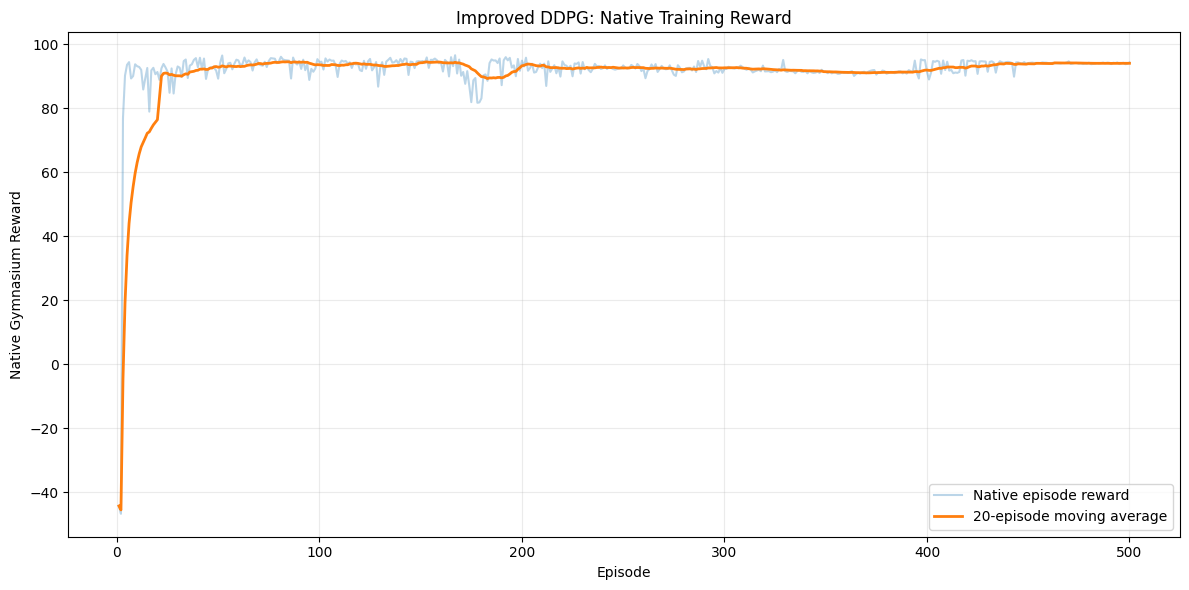

In [63]:
WINDOW = 20
native_reward_ma = history_df["native_reward"].rolling(WINDOW, min_periods=1).mean()
plt.figure(figsize=(12, 6))
plt.plot(history_df["episode"], history_df["native_reward"], alpha=0.30, label="Native episode reward")
plt.plot(history_df["episode"], native_reward_ma, linewidth=2, label="20-episode moving average")
plt.xlabel("Episode")
plt.ylabel("Native Gymnasium Reward")
plt.title("Improved DDPG: Native Training Reward")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 30. Learning reward

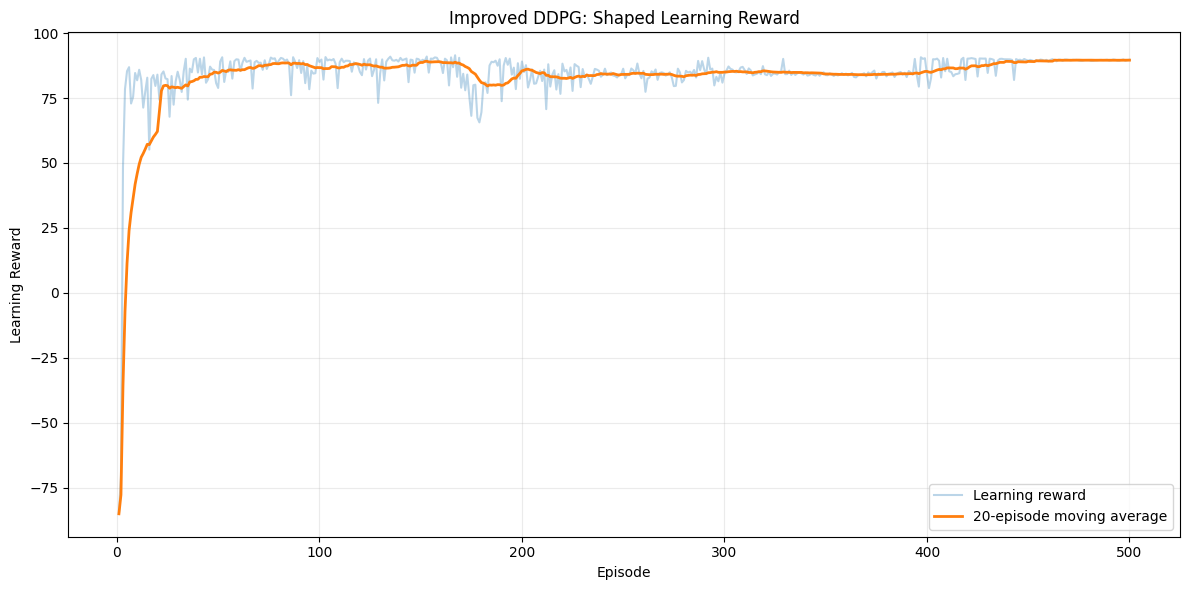

In [64]:
learning_reward_ma = history_df["learning_reward"].rolling(WINDOW, min_periods=1).mean()
plt.figure(figsize=(12, 6))
plt.plot(history_df["episode"], history_df["learning_reward"], alpha=0.30, label="Learning reward")
plt.plot(history_df["episode"], learning_reward_ma, linewidth=2, label="20-episode moving average")
plt.xlabel("Episode")
plt.ylabel("Learning Reward")
plt.title("Improved DDPG: Shaped Learning Reward")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 31. Maximum position

This is one of the most important diagnostics.

Even before successful episodes become frequent, useful learning should move:

$$
\max_t x_t
$$

toward the goal:

$$
x=0.45.
$$

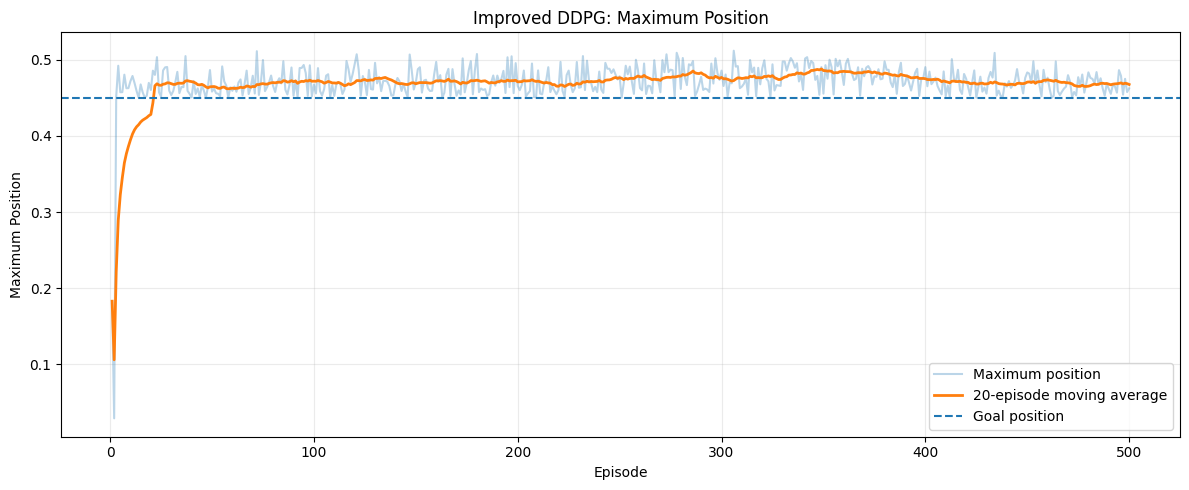

In [65]:
max_position_ma = history_df["max_position"].rolling(WINDOW, min_periods=1).mean()
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["max_position"], alpha=0.30, label="Maximum position")
plt.plot(history_df["episode"], max_position_ma, linewidth=2, label="20-episode moving average")
plt.axhline(0.45, linestyle="--", label="Goal position")
plt.xlabel("Episode")
plt.ylabel("Maximum Position")
plt.title("Improved DDPG: Maximum Position")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 32. Goal-reaching rate

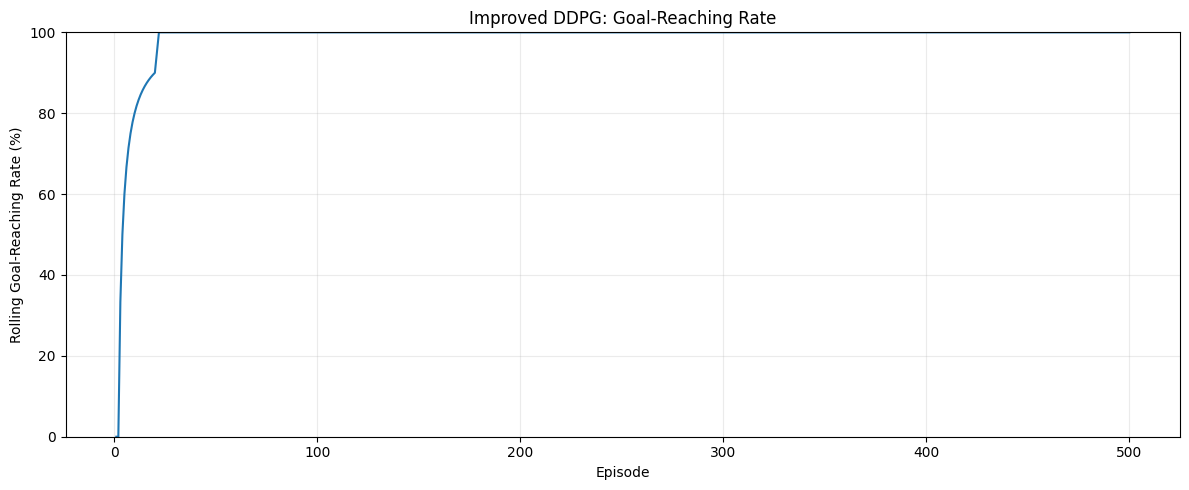

In [66]:
goal_rate = history_df["goal_reached"].rolling(WINDOW, min_periods=1).mean() * 100.0
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], goal_rate)
plt.xlabel("Episode")
plt.ylabel("Rolling Goal-Reaching Rate (%)")
plt.title("Improved DDPG: Goal-Reaching Rate")
plt.ylim(0, 100)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 33. Mean action magnitude

The source-matched failure mode produced actions close to zero.

Therefore:

$$
\boxed{
\mathbb E[|A_t|]
}
$$

is worth monitoring.

A near-zero action magnitude combined with zero success is a warning that the actor may again be collapsing to inactivity.

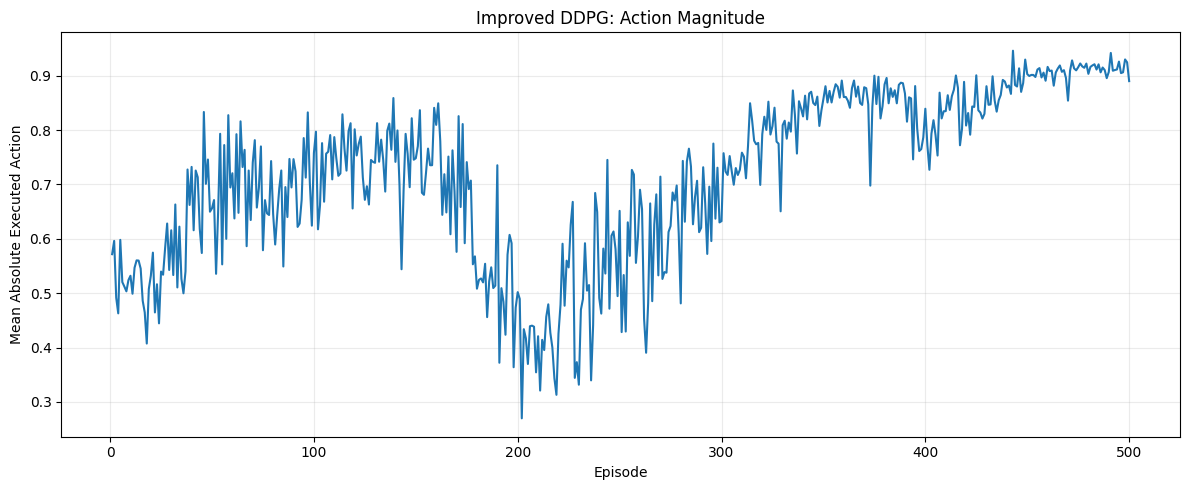

In [67]:
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["mean_abs_action"])
plt.xlabel("Episode")
plt.ylabel("Mean Absolute Executed Action")
plt.title("Improved DDPG: Action Magnitude")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 34. Exploration-noise scale

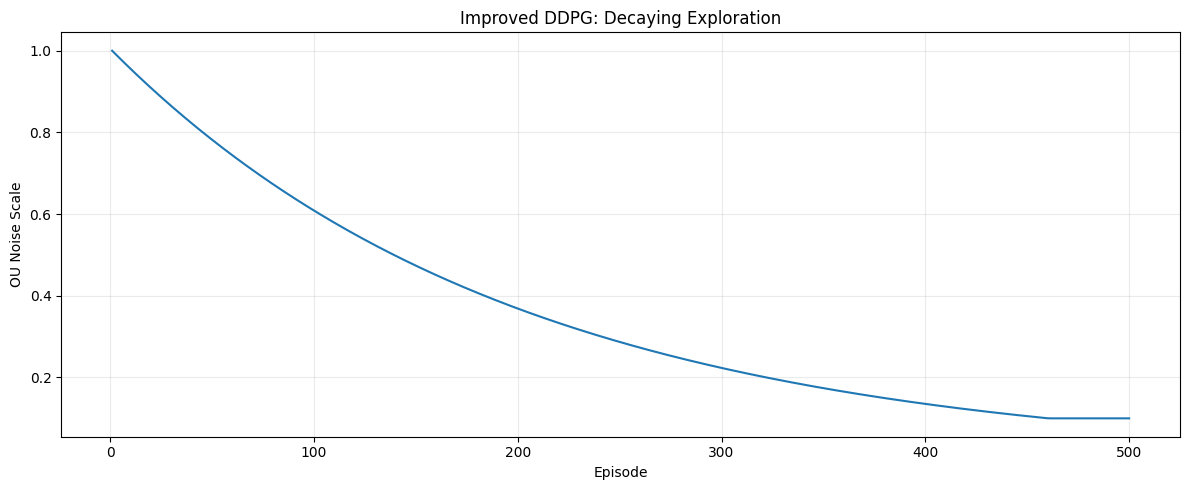

In [68]:
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["noise_scale"])
plt.xlabel("Episode")
plt.ylabel("OU Noise Scale")
plt.title("Improved DDPG: Decaying Exploration")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 35. Critic loss

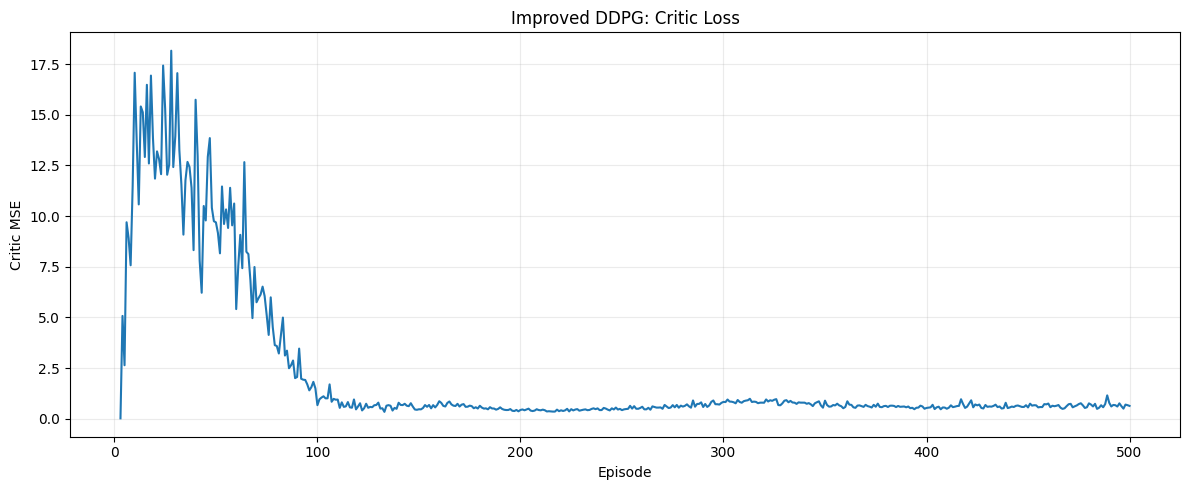

In [69]:
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["critic_loss"])
plt.xlabel("Episode")
plt.ylabel("Critic MSE")
plt.title("Improved DDPG: Critic Loss")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 36. Actor loss

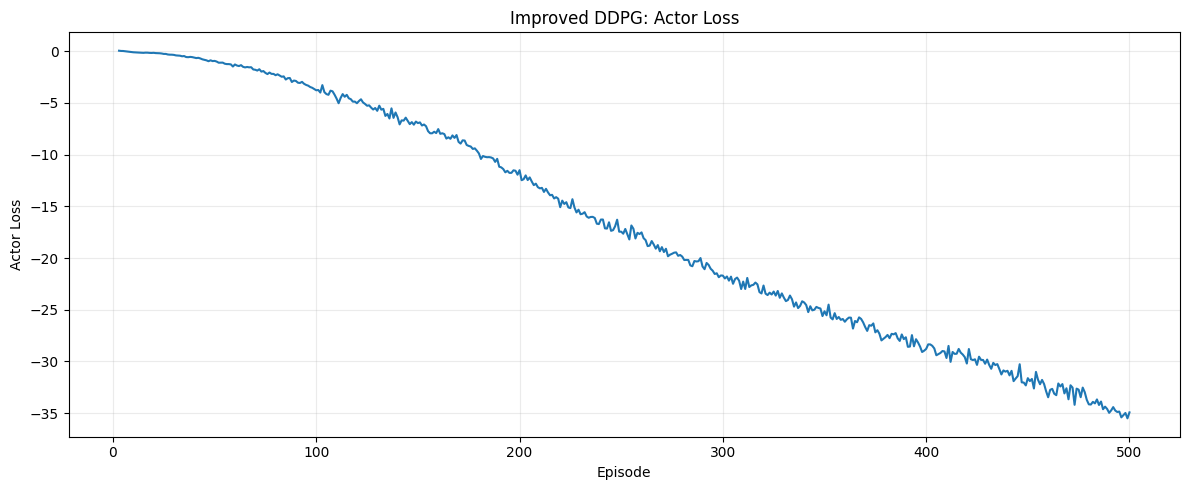

In [70]:
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["actor_loss"])
plt.xlabel("Episode")
plt.ylabel("Actor Loss")
plt.title("Improved DDPG: Actor Loss")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 37. Deterministic evaluation reward

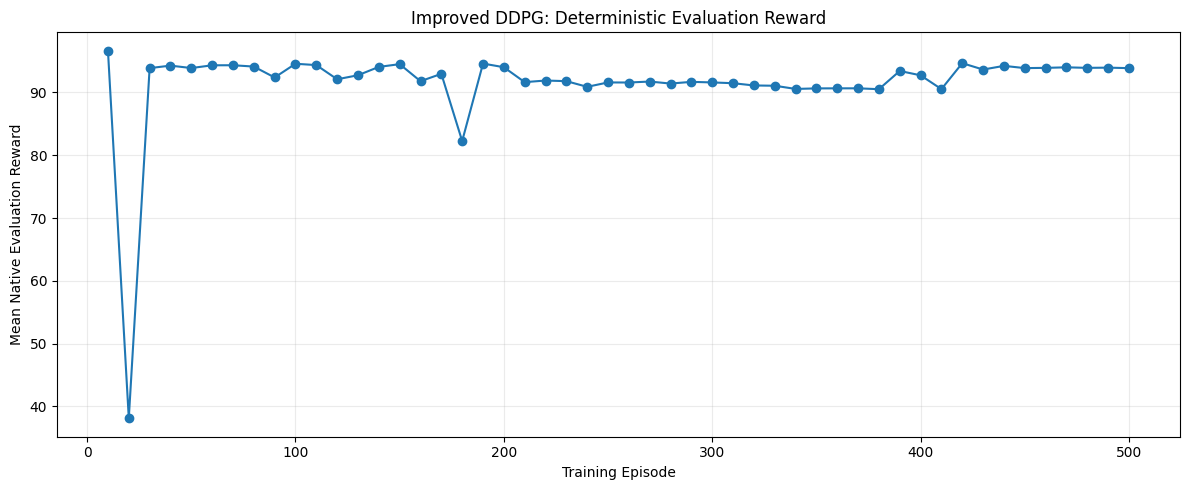

In [71]:
evaluation_df = history_df.dropna(subset=["eval_native_reward"])
plt.figure(figsize=(12, 5))
plt.plot(evaluation_df["episode"], evaluation_df["eval_native_reward"], marker="o")
plt.xlabel("Training Episode")
plt.ylabel("Mean Native Evaluation Reward")
plt.title("Improved DDPG: Deterministic Evaluation Reward")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 38. Deterministic evaluation maximum position

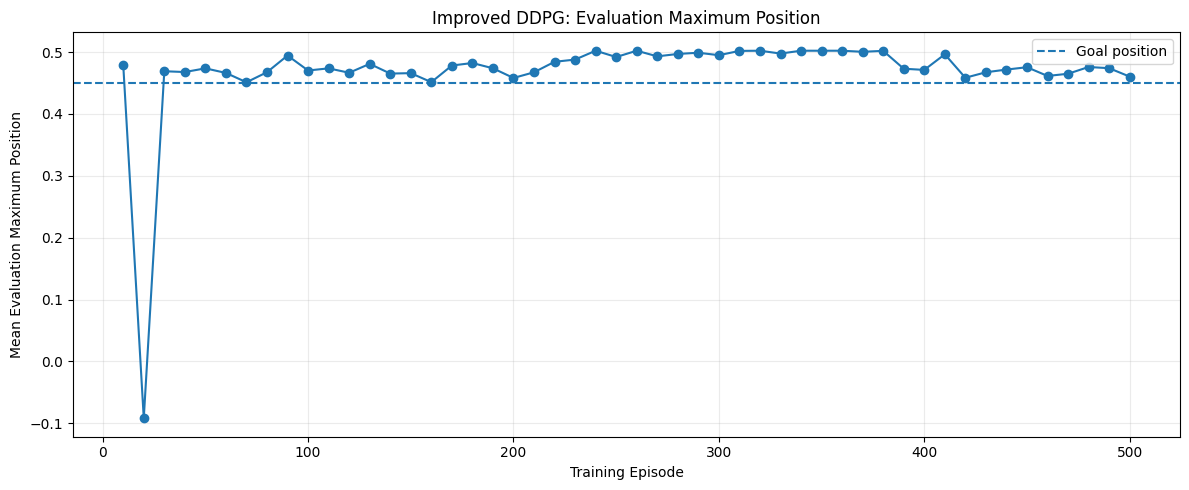

In [72]:
plt.figure(figsize=(12, 5))
plt.plot(evaluation_df["episode"], evaluation_df["eval_max_position"], marker="o")
plt.axhline(0.45, linestyle="--", label="Goal position")
plt.xlabel("Training Episode")
plt.ylabel("Mean Evaluation Maximum Position")
plt.title("Improved DDPG: Evaluation Maximum Position")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 39. Deterministic evaluation success rate

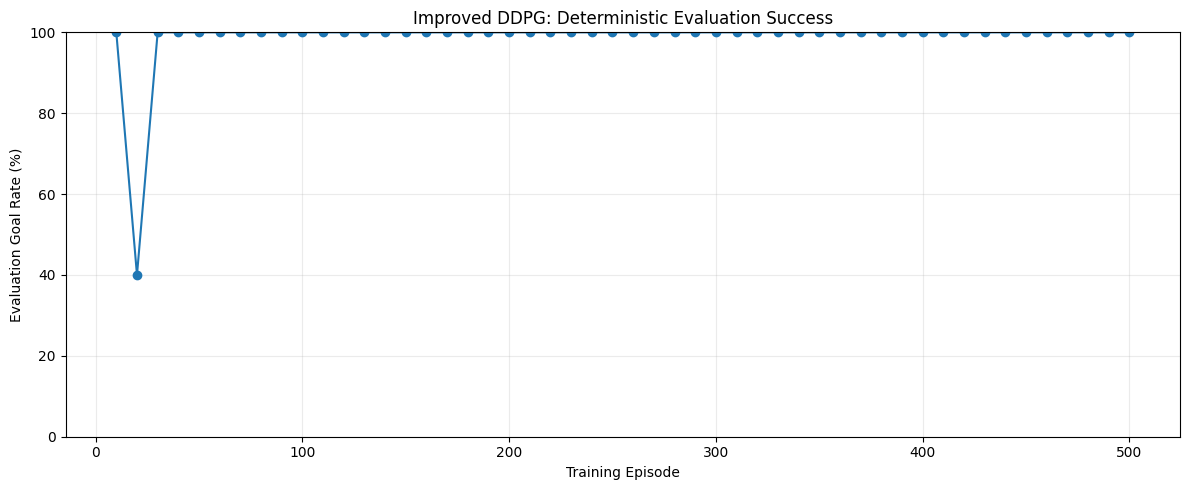

In [73]:
plt.figure(figsize=(12, 5))
plt.plot(evaluation_df["episode"], 100.0 * evaluation_df["eval_goal_rate"], marker="o")
plt.xlabel("Training Episode")
plt.ylabel("Evaluation Goal Rate (%)")
plt.title("Improved DDPG: Deterministic Evaluation Success")
plt.ylim(0, 100)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 40. Final 20-episode evaluation

In [74]:
final_evaluation = evaluate_agent(agent, episodes=20, seed=90000)
display(final_evaluation)
print("Mean native reward:", final_evaluation["native_reward"].mean())
print("Reward SD:", final_evaluation["native_reward"].std())
print("Mean episode length:", final_evaluation["length"].mean())
print("Mean maximum position:", final_evaluation["max_position"].mean())
print("Goal-reaching rate:", f'{100.0 * final_evaluation["goal_reached"].mean():.1f}%')

,episode,native_reward,length,max_position,goal_reached
0,1,94.0544,67,0.4509,True
1,2,93.8973,68,0.4772,True
2,3,93.8971,68,0.4773,True
3,4,94.0608,67,0.4530,True
4,5,93.9029,68,0.4838,True
5,6,93.9018,68,0.4801,True
6,7,93.8685,68,0.4646,True
7,8,94.0610,67,0.4530,True
8,9,93.9039,68,0.4859,True
9,10,93.9013,68,0.4774,True


Mean native reward: 93.94866292530915
Reward SD: 0.10591730431732864
Mean episode length: 67.75
Mean maximum position: 0.47213809937238693
Goal-reaching rate: 100.0%


## 41. Random-policy baseline

In [75]:
def evaluate_random_policy(episodes=20, seed=100000):
    env = gym.make("MountainCarContinuous-v0")
    records = []
    for episode in range(episodes):
        state, info = env.reset(seed=seed + episode)
        env.action_space.seed(seed + episode)
        total_reward = 0.0
        episode_length = 0
        max_position = float(state[0])
        reached_goal = False
        done = False
        while not done:
            action = env.action_space.sample()
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += float(reward)
            episode_length += 1
            max_position = max(max_position, float(next_state[0]))
            reached_goal = reached_goal or bool(terminated)
            state = next_state
        records.append({"episode": episode + 1, "native_reward": total_reward, "length": episode_length, "max_position": max_position, "goal_reached": reached_goal})
    env.close()
    return pd.DataFrame(records)

random_evaluation = evaluate_random_policy()
display(random_evaluation)
print("Random mean reward:", random_evaluation["native_reward"].mean())
print("Random mean max position:", random_evaluation["max_position"].mean())
print("Random goal-reaching rate:", f'{100.0 * random_evaluation["goal_reached"].mean():.1f}%')

,episode,native_reward,length,max_position,goal_reached
0,1,-34.7248,999,-0.3777,False
1,2,-31.5141,999,-0.2939,False
2,3,-32.8153,999,-0.1211,False
3,4,-34.0209,999,-0.0185,False
4,5,-33.5520,999,-0.3437,False
5,6,-34.4173,999,-0.3352,False
6,7,-31.5364,999,-0.0936,False
7,8,-35.2321,999,-0.2747,False
8,9,-33.3393,999,0.1284,False
9,10,-33.9546,999,0.2534,False


Random mean reward: -33.33736547870449
Random mean max position: -0.18007112797349692
Random goal-reaching rate: 0.0%


## 42. Random vs. improved DDPG

In [76]:
comparison_df = pd.DataFrame({
    "Policy": ["Random", "Improved DDPG"],
    "Mean Native Reward": [random_evaluation["native_reward"].mean(), final_evaluation["native_reward"].mean()],
    "Mean Max Position": [random_evaluation["max_position"].mean(), final_evaluation["max_position"].mean()],
    "Goal Rate (%)": [100.0 * random_evaluation["goal_reached"].mean(), 100.0 * final_evaluation["goal_reached"].mean()]
})
display(comparison_df)

,Policy,Mean Native Reward,Mean Max Position,Goal Rate (%)
0,Random,-33.3374,-0.1801,0.0
1,Improved DDPG,93.9487,0.4721,100.0


## 43. Learned policy map

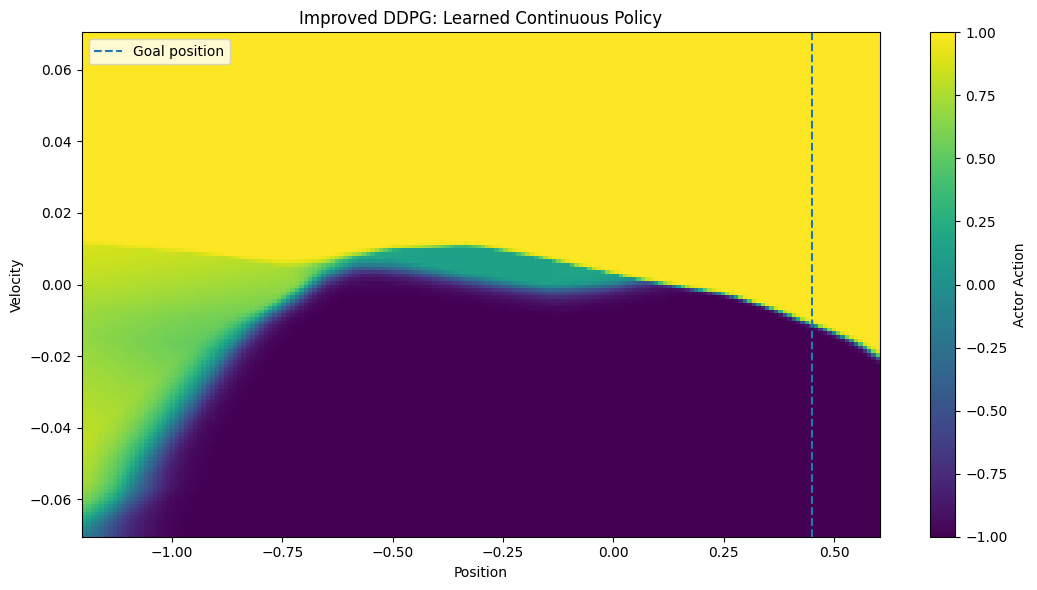

In [77]:
positions = np.linspace(-1.2, 0.6, 180)
velocities = np.linspace(-0.07, 0.07, 140)
position_grid, velocity_grid = np.meshgrid(positions, velocities)
state_grid = np.column_stack([position_grid.ravel(), velocity_grid.ravel()]).astype(np.float32)
action_grid = agent.actor(state_grid, training=False).numpy().reshape(velocity_grid.shape)
plt.figure(figsize=(11, 6))
mesh = plt.pcolormesh(position_grid, velocity_grid, action_grid, shading="auto")
plt.colorbar(mesh, label="Actor Action")
plt.axvline(0.45, linestyle="--", label="Goal position")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Improved DDPG: Learned Continuous Policy")
plt.legend()
plt.tight_layout()
plt.show()

## 44. What should a sensible learned policy look like?

A useful MountainCar policy should generally depend on velocity direction.

A common strategy is:

```text
velocity < 0
    push left

velocity > 0
    push right
```

This amplifies oscillation and gradually builds enough energy to climb the right hill.

Therefore a learned policy map should normally contain meaningful regions of both negative and positive action.

A map that is almost entirely:

$$
A_t\approx0
$$

would indicate the same inactivity collapse observed in the source-matched run.

## 45. Save the improved agent

In [78]:
agent.save(AGENT_PATH)
history_df.to_csv(os.path.join(AGENT_PATH, "training_history.csv"), index=False)
print("Saved improved agent to:", AGENT_PATH)

Saved improved agent to: mountain_car_continuous_improved


## 46. Record a deterministic evaluation video

In [79]:
def record_episode(agent, filename="mountain_car_continuous_improved.mp4", seed=110000, fps=30):
    env = gym.make("MountainCarContinuous-v0", render_mode="rgb_array")
    state, info = env.reset(seed=seed)
    frames = [env.render()]
    total_reward = 0.0
    episode_length = 0
    max_position = float(state[0])
    reached_goal = False
    done = False
    while not done:
        action = agent.greedy_action(np.asarray(state, dtype=np.float32))
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        frames.append(env.render())
        total_reward += float(reward)
        episode_length += 1
        max_position = max(max_position, float(state[0]))
        reached_goal = reached_goal or bool(terminated)
    env.close()
    imageio.mimsave(filename, frames, fps=fps)
    print("Video:", filename)
    print("Native reward:", total_reward)
    print("Episode length:", episode_length)
    print("Maximum position:", max_position)
    print("Goal reached:", reached_goal)
    return filename

video_file = record_episode(agent)
display(Video(video_file, embed=True))

Video: mountain_car_continuous_improved.mp4
Native reward: 94.06847540909143
Episode length: 67
Maximum position: 0.4539523124694824
Goal reached: True


## 47. Improved DDPG algorithm summary

```text
Initialize:
    actor
    critic

Initialize target actor:
    copy actor weights

Initialize target critic:
    copy critic weights

Initialize:
    replay memory
    OU process
    total step counter

For each episode:

    Reset environment

    Reset OU process

    Decay exploration-noise scale

    Repeat until episode ends:

        During warm-up:
            choose exploratory base action

        After warm-up:
            base action = actor(state)

        noisy action =
            base action
            + noise scale * OU noise

        executed action =
            clip(noisy action, -1, 1)

        Step environment

        Observe:
            next state
            native reward
            terminated
            truncated

        Calculate potential-based shaping

        learning reward =
            native reward
            + shaping reward

        Store:
            state
            executed action
            learning reward
            next state
            terminated

        If warm-up is complete:

            Sample replay batch

            target action =
                target actor(next state)

            target value =
                target critic(
                    next state,
                    target action
                )

            target =
                learning reward
                + gamma
                  * (1 - terminated)
                  * target value

            Update critic

            Update actor

            Soft-update target networks

    Record:
        native reward
        learning reward
        max position
        success
        action magnitude
        losses

    Periodically:
        run deterministic evaluation
```

## 48. How to judge whether this version is actually learning

Do **not** judge success from the shaped learning reward alone.

Look for all of the following:

### 1. Maximum position increases

The moving average should move toward:

$$
\boxed{x=0.45}.
$$

### 2. Goal-reaching rate becomes positive

Eventually:

$$
\boxed{\text{Goal reached = True}}
$$

should appear in training and deterministic evaluation.

### 3. Native evaluation reward improves

Evaluation uses the original environment reward with no exploration noise.

### 4. Actor actions do not collapse to zero

The mean absolute action should remain large enough to generate momentum.

### 5. Evaluation episode length falls after success

A successful policy should normally reach the goal before the full time limit.

## 49. This experiment


Shows:

- diagnosing the failure,
- correcting target initialization,
- correcting replay action consistency,
- proper terminal masking,
- controlled exploration,
- potential-based reward shaping,
- and evaluation with the untouched environment objective.

This comparison is a stronger portfolio story than silently changing the original implementation.

## References

1. Lillicrap, T. P., Hunt, J. J., Pritzel, A., et al. **Continuous control with deep reinforcement learning.**
2. Ng, A. Y., Harada, D., & Russell, S. **Policy invariance under reward transformations: Theory and application to reward shaping.**
3. Gymnasium: `MountainCarContinuous-v0`.
4. Supplied `DeepDPG` source and the source-matched MountainCarContinuous portfolio notebook.